# Hands-On AI: From Python Tools to MCP (and beyond)

In this workshop, we'll get hands-on with AI.
Enough with slogans like "AI senses its environment and acts" or "we need to become AI orchestrators" - we're here to see **the real thing** and **touch the code ourselves**.

The good news is that the tools we'll use are designed to keep the code **short and simple**.
And even better - we'll set aside concerns like security, scalability, and integrations, and focus purely on understanding the technology and having fun.

Below is our roadmap for the session:

<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/roadmap.png"/>

<hr>


## Step 1: Installation

<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/step1.png">

Before we start, let's install the software we need.
In Python, instead of installing **software** → we install a **package**.

To install the packages we'll need later, run the next cell.

What does this command do?

- `pip` - a command for installing packages (we can't use a mouse here, so we type commands 🙂).
- `install` - tells pip what to do (install the packages).
- `langchain` - the first package we install. It helps us build applications with AI models.
- `langchain-openai` - the second package we install. It lets us use OpenAI models through LangChain.

In [1]:
!pip install langchain langchain-openai


[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<hr>

## Step 2: Create a Python Tool

<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/step2.png">

Our first building block is a Python tool - something we'll gradually expand and improve throughout the workshop
(In Python, the formal term for a `Python tool` is a `Python function`).

Our made-up tool, called `mojifuzzle`, will create emojis for us:
hearts ❤️ or stars ⭐ - as many as we want.

Run the code below to create the tool.

In [2]:
def mojifuzzle(emoji_name: str, count: int) -> str:
    if emoji_name == "heart":
        return "❤️" * count
    elif emoji_name == "star":
        return "⭐" * count
    else:
        return "🤔"

Even if you don't know Python, try to guess the logic of the tool - Here are a few helpful terms:

- `def` - short for "define".
- `str` - short for "string" (text).
- `int` - short for "integer" (a whole number).
- `elif` - short for "else if".
- `*` - the sign for multiplication in Python (e.g. 2 * 3 = 6).

### 😊 Don’t worry

You don't need to fully understand the code - it’s enough to get a general idea of what it does.
Also, this is the hardest part - once we're through, the rest is much easier.

Run the next few cells and see our tool in action:

In [3]:
mojifuzzle("heart", 10)

'❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️'

In [4]:
mojifuzzle("star", 2)

'⭐⭐'

In [5]:
mojifuzzle("moon", 2)

'🤔'

*Note:* If we want to be "extra" and explain our code to others, we can write a note inside `"""` (triple quotes). Python will ignore whatever is inside - but human-beings (and AI models) can read it (spoiler alert 🙂).

Run the next cell to update `mojifuzzle` with an explanation.

In [6]:
def mojifuzzle(emoji_name: str, count: int) -> str:
    """
    Create emojis using 'heart' or 'star'.
    """
    if emoji_name == "heart":
        return "❤️" * count
    elif emoji_name == "star":
        return "⭐" * count
    else:
        return "🤔"

<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/yourturn.png" width="50%">


Update the cell below as you wish and run it to see what happens.

For example, try:

* mojifuzzle("heart", 5)

* mojifuzzle("stars", 30)

* mojifuzzle("hello", 3)

* mojifuzzle("heart", 0)

In [7]:
mojifuzzle("heart", 5)

'❤️❤️❤️❤️❤️'

<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/quick-checkpoint.png" width="50%">

<hr>


## Step 3: Turn the Python Tool into an AI Tool

<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/step3.png">

Converting a function into an AI tool is very easy. Here is the code (the added parts are clearly marked):

<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/function to ai tool.png">

In this code, we import the LangChain package (in Python, importing is like opening software we’ve already installed).

The `@tool` tells LangChain: "This function is a tool that the AI can use".

Under the hood, LangChain then converts the function into structured text that an AI model can understand:

<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/gif.gif">

Run the next cell to turn mojifuzzle into an AI tool:

In [8]:
from langchain.tools import tool

@tool
def mojifuzzle(emoji_name: str, count: int) -> str:
    """
    Create emojis using 'heart' or 'star'.
    """
    if emoji_name == "heart":
        return "❤️" * count
    elif emoji_name == "star":
        return "⭐" * count
    else:
        return "🤔"

### Optional: Under the Hood of @tool

Run the following cell to see the convertion for yourself:

In [9]:
from langchain_core.utils.function_calling import convert_to_openai_tool
import json

print(json.dumps(convert_to_openai_tool(mojifuzzle), indent=2))

{
  "type": "function",
  "function": {
    "name": "mojifuzzle",
    "description": "Create emojis using 'heart' or 'star'.",
    "parameters": {
      "properties": {
        "emoji_name": {
          "type": "string"
        },
        "count": {
          "type": "integer"
        }
      },
      "required": [
        "emoji_name",
        "count"
      ],
      "type": "object"
    }
  }
}


<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/quick-checkpoint.png" width="50%">

<hr>


## Step 4: Introduce the LLM

<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/step4.png">

To use an LLM (Large Language Model - a type of AI that can understand and generate text), run the following cell. It:

1. Import ChatOpenAI (Remember: importing is like opening software we've already installed).

2. Create the model:
- Give it a name - `llm` (We could call it anything, like `mitzi` or `david`, but we chose a meaningful name so it’s easy to recognize).
- choose a model (`gpt-4o-mini` - a simple and low-cost option).
- provide a key - Python's version for username and password.

In [ ]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini", api_key="WRITE THE KEY HERE")

That is it! just 2 lines and you can talk to an AI model!

Run the next cell and see the response (it will be presented nicely using pretty print):

In [11]:
response = llm.invoke("Introduce yourself. Which model are you?")
response.pretty_print()

================================== Ai Message ==================================

I am an AI language model developed by OpenAI, known as ChatGPT. I’m based on the GPT-3.5 architecture, designed to assist with a variety of tasks, including answering questions, providing information, and engaging in conversation. My training includes a wide range of topics up until October 2023. How can I assist you today?


<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/yourturn.png" width="50%">

Use the same code, but change the prompt.

For example, try:
- "Tell me a joke"
- "Explain what AI is in simple words"

In [12]:
response = llm.invoke("Tell me a joke")
response.pretty_print()

================================== Ai Message ==================================

Why did the scarecrow win an award?

Because he was outstanding in his field!


<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/quick-checkpoint.png" width="50%">

<hr>

## Step 5: Introduce the AI Tool to an LLM

<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/step5.png">

What do you think will happen if we ask our llm:

`please mojifuzzle 3 times with a heart`?

Run the next cell 3-4 times and see what happens.

In [20]:
response = llm.invoke("Please mojifuzzle 3 times with a heart.")
response.pretty_print()

================================== Ai Message ==================================

Sure! Here’s your request:

❤️❤️❤️ mojifuzzle mojifuzzle mojifuzzle ❤️❤️❤️


As you probably noticed, the model improvised: It tried to respond based only on the text prompt and its own reasoning - It did **not** use our `mojifuzzle` tool.

So what can we do?

We can **introduce our AI tool** to the AI model!

In technical language, we use the term "bind", meaning: we will bind the tool to the model and create an improved version.

Let's run the next cell and call it `llm_with_tools`. 

In [14]:
llm_with_tools = llm.bind_tools([mojifuzzle])

Now let's use the same prompt as before:

In [15]:
response = llm_with_tools.invoke("Please mojifuzzle 3 times with a heart.")
response.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  mojifuzzle (call_dLzZxVzSsPuGGrkDmgLGtowm)
 Call ID: call_dLzZxVzSsPuGGrkDmgLGtowm
  Args:
    emoji_name: heart
    count: 3


Wait... where are our promised hearts?

Let’s examine the output.

This time, instead of just improvising, the model says:

"I’ve seen a tool that can do this. It’s called `mojifuzzle`.  
If you use it with:

- `emoji_name="heart"`  
- `count=3`

you’ll get exactly what you want".

Not that impressive, right?

Well… let’s see what happens when things get a bit harder:

In [16]:
response = llm_with_tools.invoke("Please mojifuzzle the symbol of love for the number of sides in a triangle. Make sure to provide only a single output.")
response.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  mojifuzzle (call_g8Ln2mXJWjsn5rT217PFQJml)
 Call ID: call_g8Ln2mXJWjsn5rT217PFQJml
  Args:
    emoji_name: heart
    count: 3


<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/yourturn.png" width="50%">

Mix natural language with the tool and see if the LLM can figure out what to do. 

For example, try: "Please mojifuzzle what twinkles according to the number of continents we have."

**Tip:** Since we are using a basic model (`gpt-4o-mini`), be a bit explicit and add: "Make sure to provide only a single output."

In [17]:
response = llm_with_tools.invoke("Please mojifuzzle what twinkles according to the number of continents we have. Make sure to provide only a single output.")
response.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  mojifuzzle (call_HTCd7cL99X5a9G2UqHPwu3YH)
 Call ID: call_HTCd7cL99X5a9G2UqHPwu3YH
  Args:
    emoji_name: star
    count: 7


<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/quick-checkpoint.png" width="50%">

<hr>

## Recap

Let’s recap what we’ve done:

1. Installed the required packages using `pip`.
2. Created a Python function (`mojifuzzle`).
3. Turned it into an AI tool using `@tool`.
4. "Created" an LLM.
5. Connected our AI tool to the LLM using `bind`.

<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/summary.png">

👉 What we discovered:
- The LLM can now *recognize* when to use the tool,  
- But it still does NOT run the tool by itself.

That’s exactly what we’ll fix next.

<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/quick-checkpoint.png" width="50%">

<hr>

## The next stage: Letting AI Actually Use the Tool 

To make this work end-to-end, instead of an LLM - we need an **agent**: an agent uses an LLM **together** with tools and logic to take actions.

This is how we want our agent to work:

<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/full-flow.png" width="80%">

We can think of everything AI-related as a single "black box" - this is our **agent**.
From the outside, we interact with it and see the result.

Behind the scenes, the LLM decides what should happen next, while another component (which we won’t dive into yet) carries out those actions.

<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/full-flow-with-agent.png" width="80%">

*Note:* The term "agent" is used broadly in the AI world. In this workshop, we use it in a simple way - to describe a system that can decide what to do and perform actions, without going into the differences between various types of agents.

<hr>

Building this kind of agent is quite simple, but we'll skip it for now (you can find the code in the optional section after the workshop ends if you're curious).

Instead, we'll use a ready-made agent in Claude Desktop to show how our tool works via an MCP server.

An MCP server exposes tools in a standard way so that AI systems (like agents) can discover and use them.

<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/orchestrating.png" width="50%">

### Prerequisites
1. Install Claude Desktop.
2. Install Python.
3. Install the MCP package: `pip install mcp`.

### Step 1: Create the MCP Server

We will wrap our tool in a small MCP server:

<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/from tool to mcp server.png">

Copy the following code into a separate Python file (for example, server.py on our Desktop):

```python
from mcp.server.fastmcp import FastMCP

mcp = FastMCP("Mojifuzzle server")

@mcp.tool()
def mojifuzzle(emoji_name: str, count: int) -> str:
    """
    Create emojis using 'heart' or 'star'.
    """
    if emoji_name == "heart":
        return "❤️" * count
    elif emoji_name == "star":
        return "⭐" * count
    else:
        return "🤔"

if __name__ == "__main__":
    mcp.run()
```

### Step 2: Register the Server in Claude Desktop

1. Open Claude Desktop.
2. Go to Settings → Developers → Edit Config.
3. Open the claude_desktop_config.json file.
4. Add the server under mcpServers:

```json
{
  "mcpServers": {
    "mojifuzzle-server": {
      "command": "C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python310\\python.exe",
      "args": ["C:\\Users\\User\\Desktop\\server.py"]
    }
  },
  "preferences": {
    "coworkWebSearchEnabled": true,
    "coworkScheduledTasksEnabled": false,
    "ccdScheduledTasksEnabled": false,
    "sidebarMode": "chat"
  }
}
```

Note that this is just an example - You must replace:
- command → with your Python executable path.
- args → with your server.py path.
- On Windows, use double backslashes (\\).

### Step 3: Restart and Validate
1. Restart Claude Desktop.
2. Go to Settings → Developers.
3. Verify your server appears and is running.

<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/claude-mcp1.JPG">

### Step 4: Use the Tool in Claude Desktop

1. Start a new chat.
2. Click the + (Connectors) menu and enable `mojifuzzle-server`.

<img src="https://raw.githubusercontent.com/mhornstein/AI_Foundations_Workshop/main/images/claude-mcp2.JPG">

3. Run: `Please mojifuzzle 3 times with a heart`.
4. When prompted, click *Approve* to allow the tool to run.
5. Now turn the connector off and run the same prompt again. Did the model still succeed?

### Step 5: Try More Advanced Prompts
For example:
- `Please mojifuzzle the symbol of love for the number of sides in a triangle`.
- `Please mojifuzzle what twinkles according to the number of continents we have. Make sure to provide only a single output`.

<hr>

## Optional: Build Your Own Agent from Scratch

If you're curious how to build the agent we discussed above using LangGraph, here’s how you can do it.

Note: There are easier ways to build agents. Here, we go a bit more "under the hood" so you can really see how things work.

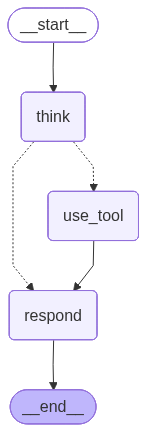

In [23]:
from langgraph.graph import StateGraph
from IPython.display import Image
from typing import TypedDict, Any

class AgentState(TypedDict, total=False):
    input: str
    response: Any
    tool_output: str
    output: str

# Step 1: Ask the model what to do
def think(state):
    response = llm_with_tools.invoke(state["input"])
    return {
        **state,
        "response": response
    }

# Step 2: Decide if we need to use a tool
def should_use_tool(state):
    if state["response"].tool_calls:
        return "use_tool"
    return "respond"

# Step 3: Execute the tool
def use_tool(state):
    tool_call = state["response"].tool_calls[0]
    tool_output = mojifuzzle.invoke(tool_call["args"])
    
    return {
        **state,
        "tool_output": tool_output
    }

# Step 4: Return final answer
def respond(state):
    if "tool_output" in state:
        return {
            **state,
            "output": state["tool_output"]
        }
    
    return {
        **state,
        "output": state["response"].content
    }

# Build graph
graph = StateGraph(AgentState)

graph.add_node("think", think)
graph.add_node("use_tool", use_tool)
graph.add_node("respond", respond)

graph.set_entry_point("think")

graph.add_conditional_edges(
    "think",
    should_use_tool,
    {
        "use_tool": "use_tool",
        "respond": "respond"
    }
)

graph.add_edge("use_tool", "respond")

app = graph.compile()

# Visualize the graph
Image(app.get_graph().draw_mermaid_png())

Now use the agent:

In [26]:
# Run it
result = app.invoke({
    "input": "Please mojifuzzle 3 hearts"
})

print(result["output"])

❤️❤️❤️


## Summary

In this workshop, you:

1. Defined a Python function ("tool"), exposed it to an LLM using LangChain's `@tool`, and saw how `@tool` represents it to the LLM.
2. Interacted with an LLM and gave it access to tools (`bind_tools`).
3. Understood the key difference between an LLM *suggesting* an action and a system actually *executing* it.
4. Used the MCP protocol to expose tools in a standardized way for AI systems (e.g., Claude Desktop).

## Interested in going further?

You can explore:

1. **Skills**: How to take the tool we built and package it as a reusable skill.
2. **Sub-agents**: How to use the same tool within a system of multiple agents.
3. **MCP vs. Skills vs. Sub-agents**: If the same tool can be used across different approaches - what should you choose, and when?